[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Extra/X1-FeatureSelection.ipynb)

# X1 — Choosing Features When Most of Them Are Useless

(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Extra material — optional: not covered in the lectures, and not examinable**

**When to read it:** any time after Class 5. It uses cross-validation and pipelines (`02C`), the lasso (`03C` §4), feature importance (`04B` §7) and the distance argument of `05A` §4.2.

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

This notebook and `X2` are extra reading. Nothing in them is required for the midterm or the final,
and no lecture time is spent on them. They exist because the course raises a problem it never
solves.

`05A` §4.2 measured it: fifty columns of pure noise added to ten real measurements cost a
nearest-neighbour model 0.12 of ROC AUC. `03C` §4 taught one way of selecting features — the lasso —
and said in as many words that the course teaches no other. `04B` §7 showed that feature importance
rankings mislead in three separate ways. A student who leaves with those three facts and nothing
else is not equipped for a table where most of the columns are noise.

**That table is the normal case outside a physics lab.** In finance it is the defining case: hundreds
of candidate signals, a handful of which carry anything, and a target that is mostly noise. The same
shape appears in high-throughput screening, in genomics, in any long log of sensor channels. This
notebook is about what to do then — and, just as important, about how such work fools the people who
do it.

## Learning Objectives

By the end of this notebook, students should be able to:

- explain the **winner's curse**: why the best of many useless features looks good, and by how much;
- state why **selection is part of the model**, and score it with the selection inside the
  resampling loop;
- use **nested cross-validation** where a selection step and a hyperparameter search are both
  present;
- name the three families of selection — **filter, wrapper, embedded** — and their costs;
- prefer **how often a feature is chosen** to a single ranking, and say what correlated features do
  to that;
- say what to report about a selection procedure, and when selection is the wrong answer.

## Where this sits in the pipeline

Feature selection is step 5.4 of the map — but the point of this notebook is that it cannot stay
there. Anything fitted to the target belongs **inside** step 8's loop, or the score in step 9 is a
fiction.

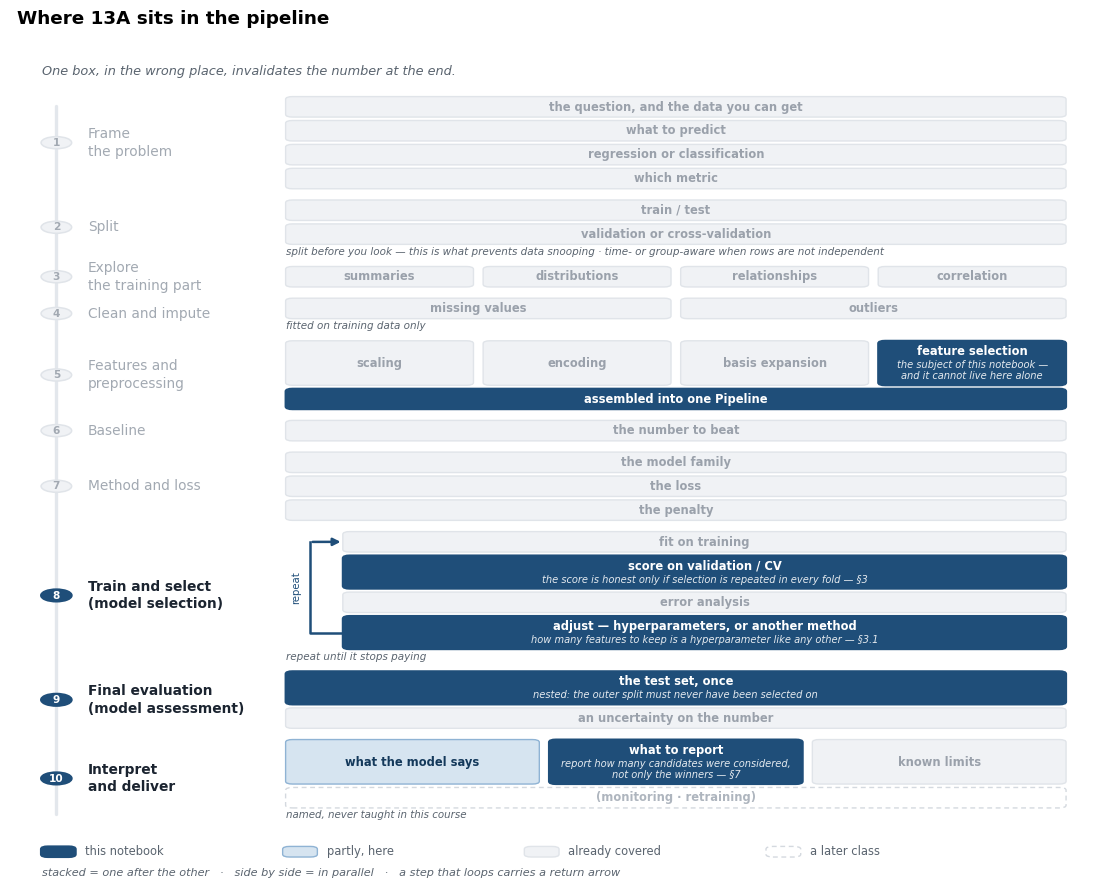

In [ ]:
# Infrastructure, not material. The map below is drawn by one helper file kept with
# the course; Colab has no copy of the repository, so fetch it when it is not already here.
import os, sys, urllib.request
import matplotlib.pyplot as plt

for folder in (".", "..", "../.."):
    if os.path.exists(f"{folder}/pipeline_map.py"):
        sys.path.insert(0, folder)
        break
else:
    urllib.request.urlretrieve("https://raw.githubusercontent.com/MarcoBattiato/"
                               "PH6721-Deep-Learning-with-Python/main/pipeline_map.py",
                               "pipeline_map.py")
from pipeline_map import pipeline_map

pipeline_map(
    {"1": "done", "2": "done", "3": "done", "4": "done", "5": "done", "5.4": "now",
     "5.after": "now", "6": "done", "7": "done",
     "8.1": "done", "8.2": "now", "8.3": "done", "8.4": "now",
     "9.1": "now", "9.2": "done", "10.1": "part", "10.2": "now", "10.3": "done"},
    notes={"5.4": "the subject of this notebook — and it cannot live here alone",
           "5.after": "the selector goes inside the Pipeline, with everything else — §3",
           "8.2": "the score is honest only if selection is repeated in every fold — §3",
           "8.4": "how many features to keep is a hyperparameter like any other — §3.1",
           "9.1": "nested: the outer split must never have been selected on",
           "10.2": "report how many candidates were considered, not only the winners — §7"},
    title="Where 13A sits in the pipeline",
    lead="One box, in the wrong place, invalidates the number at the end.")
plt.show()

In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold

plt.rcParams.update({
    "figure.dpi": 110, "figure.autolayout": True, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 10,
})

rng = np.random.default_rng(0)

# 1. A table where the truth is known

Real data will not tell you which of its columns matter, so every claim below is made on **simulated
data where the answer is known**: $n$ samples, $p$ features drawn independently from a standard
normal, and a target built from the first $k$ of them plus noise. Everything else is a decoy.

$$
y_i \;=\; \beta \sum_{j=1}^{k} x_{ij} \;+\; \varepsilon_i ,
\qquad \varepsilon_i \sim \mathcal{N}(0, 1)
$$

The default below is 250 samples, 500 features, 5 of which are real: wider than it is long, which is
the regime this notebook is about. A financial cross-section, a gene-expression study and a sensor
log all have that shape.

In [ ]:
def make_table(n=250, p=500, k=5, beta=0.5, seed=1):
    """A table with k informative features among p, and the truth alongside it."""
    draw = np.random.default_rng(seed)
    X = draw.normal(size=(n, p))
    y = X[:, :k] @ np.full(k, beta) + draw.normal(0, 1.0, n)
    return X, y, np.arange(k)          # the informative columns are the first k, by construction


X, y, informative = make_table()
print(f"{X.shape[0]} samples, {X.shape[1]} features, {len(informative)} of them informative")
print(f"share of the variance of y explained by the five real features: "
      f"{1 - 1.0 / np.var(y):.2f}")

250 samples, 500 features, 5 of them informative
share of the variance of y explained by the five real features: 0.61


# 2. The winner's curse

Before selecting anything, it is worth seeing what a table of **pure noise** offers. The cell below
takes 250 samples and 500 features, none of which has any relationship with the target, and asks the
question every screening procedure asks: which feature correlates best?

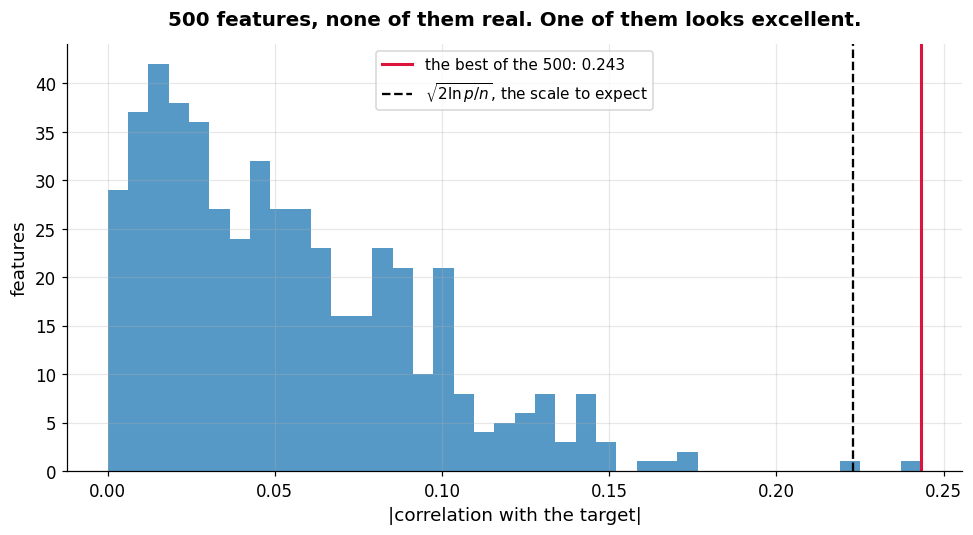

median |correlation| over the 500 features: 0.045
best |correlation|:                         0.243

R2 of the winning feature, on the data that chose it: +0.059
R2 of the same feature, on fresh data:                -0.066


In [ ]:
noise_X = rng.normal(size=(250, 500))
noise_y = rng.normal(size=250)
correlations = np.array([abs(np.corrcoef(noise_X[:, j], noise_y)[0, 1]) for j in range(500)])
winner = correlations.argmax()

fig, axis = plt.subplots(figsize=(9, 5))
axis.hist(correlations, bins=40, color="tab:blue", alpha=0.75)
axis.axvline(correlations[winner], color="crimson", linewidth=2,
             label=f"the best of the 500: {correlations[winner]:.3f}")
axis.axvline(np.sqrt(2 * np.log(500) / 250), color="black", linestyle="--", linewidth=1.5,
             label=r"$\sqrt{2\ln p / n}$, the scale to expect")
axis.set_xlabel("|correlation with the target|")
axis.set_ylabel("features")
axis.set_title("500 features, none of them real. One of them looks excellent.")
axis.legend()
plt.show()

fresh_X = rng.normal(size=(5000, 500))
fresh_y = rng.normal(size=5000)
champion = LinearRegression().fit(noise_X[:, [winner]], noise_y)
print(f"median |correlation| over the 500 features: {np.median(correlations):.3f}")
print(f"best |correlation|:                         {correlations[winner]:.3f}")
print(f"\nR2 of the winning feature, on the data that chose it: {champion.score(noise_X[:, [winner]], noise_y):+.3f}")
print(f"R2 of the same feature, on fresh data:                {champion.score(fresh_X[:, [winner]], fresh_y):+.3f}")

There is no signal in that table at all, and still one feature correlates with the target at 0.243
— five times the median. Fitted on the data that chose it, it explains 5.9% of the variance. On
fresh data it explains nothing: its $R^2$ is **negative**, meaning it is worse than predicting the
mean.

The dashed line is the scale to expect. For $p$ independent noise features and $n$ samples the
largest correlation grows like $\sqrt{2 \ln p / n}$, which is 0.223 here — so the observed 0.243 is
not bad luck, it is the typical outcome. Note what it depends on: the number of features you
**looked at**, not the number you kept. Searching a thousand candidates and reporting the best is a
different experiment from testing one candidate, and only the second is what a p-value or an $R^2$
describes.

> **The winner's curse.** The best of many noisy estimates is biased upwards, and the more
> candidates you screen, the larger the bias. The selection step itself is what does the damage,
> whether or not the features are real.

This is the same effect as `02C` §6.1's leak, but it arrives from the other direction: there the
correlations were computed on data that included the test rows; here every correlation is honest,
and the *choice* is what misleads.

# 3. Selection is part of the model

The consequence is the single most important rule in this notebook. **A selector that looks at the
target is a fitted object, exactly like a coefficient.** Fit it on all the data and then
cross-validate what follows, and the folds have already seen, through the selection, the very rows
they are supposed to score.

The cell below runs both versions on the table of section 1 — the honest one puts `SelectKBest`
inside a `Pipeline`, so `cross_val_score` refits it in every fold, which is `02C` §6.3's remedy — and
does it at three strengths of signal.

In [ ]:
folds = KFold(n_splits=5, shuffle=True, random_state=0)
print(f"{'signal beta':>12}{'selected first, then scored':>30}{'selection inside the folds':>30}")
for beta in [0.25, 0.5, 1.0]:
    X_b, y_b, truth = make_table(beta=beta)

    # WRONG: the 20 best features are chosen using every row, and only then cross-validated
    chosen = SelectKBest(f_regression, k=20).fit(X_b, y_b).get_support(indices=True)
    optimistic = cross_val_score(LinearRegression(), X_b[:, chosen], y_b, cv=folds, scoring="r2")

    # RIGHT: the selection is a step of the pipeline, refitted inside every fold
    honest = cross_val_score(make_pipeline(SelectKBest(f_regression, k=20), LinearRegression()),
                             X_b, y_b, cv=folds, scoring="r2")

    print(f"{beta:>12}{optimistic.mean():>30.3f}{honest.mean():>30.3f}")

 signal beta   selected first, then scored    selection inside the folds
        0.25                         0.322                        -0.037


         0.5                         0.597                         0.411
         1.0                         0.812                         0.799


At the weakest signal the difference decides whether the model is worth anything: **+0.322 selected
first, −0.037 done properly.** The first number would go into a report as "the model explains about
a third of the variance"; the truth is that it explains none of it. At the strongest signal the two
nearly agree, because the five real features dominate the selection whatever rows it sees. You
cannot tell in advance which regime you are in, which is the argument for always doing it the second
way.

This is one of the oldest known traps in applied machine learning, and it has a canonical treatment:
*The Elements of Statistical Learning*, ch. 7.10.2, "The wrong and right way to do cross-validation".
Ambroise and McLachlan (*PNAS* 99, 2002) found it in published cancer-classification papers, where
selecting genes before cross-validating produced near-perfect accuracies on data with no signal.

## 3.1 When there is a search as well: nested cross-validation

Selecting **how many** features to keep is itself a hyperparameter, so it must be chosen the way
`02C` §4 chooses any hyperparameter — on validation data — and the score that is finally reported
must come from data that neither the selection nor the search has seen. That is **nested**
cross-validation: an inner loop that chooses, an outer loop that scores.

In [ ]:
searched = GridSearchCV(make_pipeline(SelectKBest(f_regression), LinearRegression()),
                        {"selectkbest__k": [2, 5, 10, 20, 50, 100]},
                        cv=5, scoring="r2")

# The inner loop chooses k.  Its own best score is not an estimate of anything: it is the best of
# six, on the folds that chose it — the winner's curse again, at the level of hyperparameters.
searched.fit(X, y)
print(f"best k, chosen by the inner search: {searched.best_params_['selectkbest__k']}")
print(f"the inner search's own best score : {searched.best_score_:+.3f}   (optimistic)")

# The outer loop refits the whole search inside each of its folds, and scores on rows that the
# search never touched.
nested = cross_val_score(searched, X, y, cv=folds, scoring="r2")
print(f"nested cross-validated score      : {nested.mean():+.3f} +/- {nested.std():.3f}")

best k, chosen by the inner search: 5
the inner search's own best score : +0.566   (optimistic)


nested cross-validated score      : +0.543 +/- 0.131


The inner search reports the best of six settings on the folds that chose it; the nested score is
what the procedure is worth on data it has not seen. The gap is small here and large when the search
is large — Cawley and Talbot (*JMLR* 11, 2010) collected published results whose entire claimed
improvement was this gap. Varma and Simon (*BMC Bioinformatics* 7, 2006) measured it for feature
selection specifically.

The cost is a factor of the number of outer folds: five outer folds mean the search runs five times.
That is the price of a number you can defend.

> **Anything fitted to the target goes inside the loop.** Selection, imputation, scaling, the choice
> of $k$, the choice of model. If it looked at $y$, it is part of the model.

# 4. The three families, side by side

`03C` §4 gave the standard taxonomy (Guyon & Elisseeff, *JMLR* 3, 2003). Here all three run on the
same table, where the truth is known.

- **Filter** — score each feature against the target on its own and keep the best. `SelectKBest`
  with an F-test is the usual form. Fast, blind to interactions, and it cannot notice that two
  features carry the same information.
- **Wrapper** — search over *subsets*, scoring each by fitting a model. Recursive feature
  elimination fits, drops the weakest features, and repeats. With a linear SVM this is **SVM-RFE**
  (Guyon, Weston, Barnhill & Vapnik, *Machine Learning* 46, 2002), for years the standard method in
  gene selection — and the one place where a support vector machine does select features.
- **Embedded** — the fit does the selecting. Lasso sets coefficients to exactly zero (`03C` §4); a
  tree ensemble ranks features by how much they were used (`04B` §7).

In [ ]:
def score_selection(name, picked, seconds):
    """How many of the five real features were found, and how much else came with them."""
    found = len(set(picked) & set(informative))
    print(f"{name:34}{len(picked):>8}{found:>7}/5{len(picked) - found:>10}{seconds:>9.1f}")


print(f"{'':34}{'kept':>8}{'real':>9}{'spurious':>10}{'seconds':>9}")

start = time.time()
by_filter = SelectKBest(f_regression, k=20).fit(X, y).get_support(indices=True)
score_selection("filter: F-test, keep 20", by_filter, time.time() - start)

start = time.time()
alpha = LassoCV(cv=5, random_state=0).fit(X, y).alpha_
by_lasso = np.flatnonzero(Lasso(alpha=alpha).fit(X, y).coef_)
score_selection("embedded: lasso, alpha by CV", by_lasso, time.time() - start)

start = time.time()
by_forest = np.argsort(RandomForestRegressor(300, n_jobs=-1, random_state=0)
                       .fit(X, y).feature_importances_)[::-1][:20]
score_selection("embedded: forest, top 20", by_forest, time.time() - start)

start = time.time()
by_wrapper = np.flatnonzero(RFE(SVR(kernel="linear"), n_features_to_select=20, step=0.2)
                            .fit(X, y).support_)
score_selection("wrapper: SVM-RFE, keep 20", by_wrapper, time.time() - start)

                                      kept     real  spurious  seconds
filter: F-test, keep 20                 20      5/5        15      0.0


embedded: lasso, alpha by CV            57      5/5        52      0.6


embedded: forest, top 20                20      5/5        15      2.8


wrapper: SVM-RFE, keep 20               20      5/5        15      1.2


All four find all five real features, and all four bring a crowd of spurious ones with them: fifteen
each for the methods that were told to keep twenty, and **fifty-two** for the lasso, whose
cross-validated $\alpha$ is tuned for prediction rather than for sparsity. That last point is worth
keeping: *the penalty that predicts best is not the penalty that selects best*, and a lasso used as
a selector will usually keep more features than you want.

Two pieces of standard vocabulary:

- **Minimal-optimal versus all-relevant** (Nilsson et al., *JMLR* 8, 2007). Do you want the smallest
  set that predicts as well as possible, or every feature that carries information about the target?
  Lasso and RFE answer the first; methods such as **Boruta** (Kursa & Rudnicki, 2010) answer the
  second. They give different answers when features are correlated, and asking for one while
  measuring the other is a common confusion.
- **False discovery rate.** A filter is a multiple-testing problem, and the standard control is
  Benjamini–Hochberg (1995); `scikit-learn` offers it as `SelectFdr`. "Keep the top 20" controls
  nothing at all.

# 5. Ask how often, not which

A single run gives a single set. Run it again on a slightly different sample and the set changes —
and there is no way to tell, from one run, which members were chosen for a reason.

**Stability selection** (Meinshausen & Bühlmann, *JRSS-B* 72, 2010) answers the better question. Fit
the selector many times on random halves of the data, count how often each feature is kept, and keep
those whose frequency passes a threshold. The count is the output; the individual runs are not.

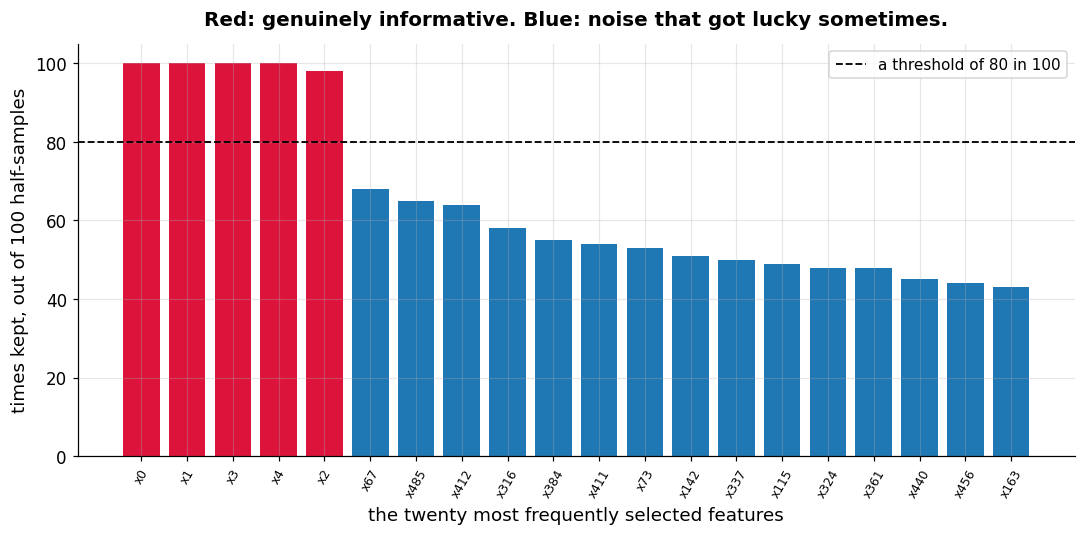

the five real features were kept   : [100 100  98 100 100] times out of 100
the most persistent noise feature  : 68 times
noise features above the threshold : 0

for comparison, one lasso on all the data kept 57 features, 52 of them spurious


In [ ]:
def selection_frequency(X_data, y_data, alpha, rounds=100, seed=0):
    """How often each feature survives a lasso fitted to a random half of the rows."""
    draw = np.random.default_rng(seed)
    counts = np.zeros(X_data.shape[1])
    for _ in range(rounds):
        rows = draw.choice(len(y_data), len(y_data) // 2, replace=False)
        counts[Lasso(alpha=alpha).fit(X_data[rows], y_data[rows]).coef_ != 0] += 1
    return counts


counts = selection_frequency(X, y, alpha)
order = np.argsort(counts)[::-1]

fig, axis = plt.subplots(figsize=(10, 5))
axis.bar(range(20), counts[order[:20]],
         color=["crimson" if j in informative else "tab:blue" for j in order[:20]])
axis.axhline(80, color="black", linestyle="--", linewidth=1.2, label="a threshold of 80 in 100")
axis.set_xticks(range(20), [f"x{j}" for j in order[:20]], rotation=60, fontsize=8)
axis.set_xlabel("the twenty most frequently selected features")
axis.set_ylabel("times kept, out of 100 half-samples")
axis.set_title("Red: genuinely informative. Blue: noise that got lucky sometimes.")
axis.legend()
plt.show()

print(f"the five real features were kept   : {counts[informative].astype(int)} times out of 100")
print(f"the most persistent noise feature  : {int(counts[5:].max())} times")
print(f"noise features above the threshold : {int((counts[5:] >= 80).sum())}")
print(f"\nfor comparison, one lasso on all the data kept {len(by_lasso)} features, "
      f"{len(by_lasso) - len(informative)} of them spurious")

The five real features survive 98 to 100 times out of 100. The luckiest noise feature manages 68. A
threshold at 80 therefore recovers exactly the five, where the single lasso of section 4 offered
fifty-seven features with no way of telling which were which.

That is the practical value: **a frequency is interpretable and a ranking is not.** It also costs
what it looks like it costs — a hundred fits instead of one — which is affordable for a lasso and is
not for a deep network, a limitation worth knowing before promising it.

> Stability selection has assumptions of its own, and the exchange of a threshold for an error bound
> is not free; Shah and Samworth (*JRSS-B* 75, 2013) give the version with the guarantee. Treat the
> threshold as a knob you chose, and say what you chose.

# 6. What correlated features do to all of this

`03C` §4 showed lasso choosing arbitrarily between `s1` and `s2`, two blood measurements correlated
at 0.90. The same effect breaks the method of section 5, and it is worth seeing directly.

The cell adds four near-copies of the first real feature — correlations around 0.95, as if the same
quantity had been recorded by five instruments — and repeats both the fit and the frequency count.

In [ ]:
copy_rng = np.random.default_rng(5)
copies = np.column_stack([X[:, 0] + copy_rng.normal(0, 0.33, len(y)) for _ in range(4)])
X_copies = np.column_stack([X, copies])
family = [0] + [500 + j for j in range(4)]           # the original and its four near-copies

print("correlation of each copy with the original:",
      [round(float(np.corrcoef(X_copies[:, 0], X_copies[:, 500 + j])[0, 1]), 2) for j in range(4)])

alpha_copies = LassoCV(cv=5, random_state=0).fit(X_copies, y).alpha_
coefficients = Lasso(alpha=alpha_copies).fit(X_copies, y).coef_
print(f"\nlasso coefficients on the five members of the family: {coefficients[family].round(3)}")
print(f"   kept: {int((coefficients[family] != 0).sum())} of 5")

counts_copies = selection_frequency(X_copies, y, alpha_copies)
print(f"\nhow often each member of the family survives: {counts_copies[family].astype(int)} / 100")
print(f"the other four real features, for comparison: {counts_copies[1:5].astype(int)} / 100")

correlation of each copy with the original: [0.96, 0.96, 0.95, 0.96]



lasso coefficients on the five members of the family: [0.096 0.339 0.    0.    0.   ]
   kept: 2 of 5



how often each member of the family survives: [34 91 12 27 30] / 100
the other four real features, for comparison: [100  98 100 100] / 100


The five members of the family carry the same information, and between them they hold one real
effect. Lasso keeps two of them and assigns most of the weight to a copy rather than to the
original. Worse, the frequencies collapse: the members are selected 34, 91, 12, 27 and 30 times,
while the four untouched real features stay at 98 to 100. **A threshold of 80 now discards four of
the five, and would have discarded the effect entirely if the copies had shared the votes more
evenly.**

Nothing is wrong with the data, and nothing is wrong with stability selection. The unit of analysis
is wrong. When features come in correlated groups, the group is what carries the information, and it
is what should be selected:

- **Cluster first, then treat each cluster as one feature** — `04B` §7.2's recipe: Spearman
  correlations, hierarchical clustering, one representative per cluster.
- **Group lasso** (Yuan & Lin, *JRSS-B* 68, 2006) penalises whole groups, so a group enters or
  leaves together, when the grouping is known in advance.
- **Elastic net** (`03C` §4) is the soft version: its L2 part makes correlated features enter
  together rather than one at a time.

> **Check the correlation structure before you select, not after.** Every method in section 4
> assumes the features are distinguishable. When they are not, the method will still return an
> answer, and the answer will be arbitrary.

# 7. What to report

A selection procedure is part of the method, so it belongs in the write-up with the same care as the
model. Four things, none of them optional:

**How many candidates were considered.** Not how many were kept. Section 2 shows why: the bias in
the reported performance is set by the size of the search. "We screened 400 candidate signals and
kept 6" is a different claim from "we used 6 features".

**Where the selection happened.** Inside the cross-validation, or before it. If before, the reported
score is not an estimate of out-of-sample performance and should not be presented as one.

**How stable the choice is.** A frequency across resamples (section 5), or at minimum the admission
that a single run was used and the set would change under another.

**What the features are, and are not.** `04B` §7's warning applies with full force: a selected set is
a statement about this model on this sample, not about which quantities matter in the world. Two
correlated features are interchangeable to the procedure and are usually not interchangeable to the
physics.

The closing procedure of `03C` §8, `04A` §13, `04B` §12, `04C` §12 and `05A` §7 changes in exactly
one place when selection is present: **step 2 grows a selector, and step 4's search runs inside the
outer folds**. Nothing else moves.

# 8. When selection is not the answer

**When the features have structure.** Pixels, samples of a waveform, tokens of a sequence: there is
no useless column to drop, and the right move is an architecture that exploits the structure —
Classes 10 to 12 — or a transform that reveals it. Selecting individual pixels is almost never
sensible.

**When the features are many and jointly weak.** If a hundred features each carry a little and none
carries much, a selector that keeps ten throws most of the signal away. Shrinkage — ridge (`03C`) —
or a projection that combines them — PCA (`06A`) — keeps it instead. The choice between selecting
and projecting is a modelling decision: selection keeps columns you can name, projection keeps
directions you usually cannot.

**When a representation can be learned.** This is the deep-learning answer, and `05A` §5.1 states
its limits: a learned representation replaces hand-built features when there is structure to learn
from and enough data to learn it. On a plain table of measurements, a boosted model on sensibly
chosen features remains the thing to beat (`04C` §9), and the evidence there is explicit that
uninformative features are one of the reasons neural networks struggle on tables.

**When the cost is not accuracy.** Sometimes features are dropped because measuring them is
expensive, because a regulator needs an explainable model, or because a sensor drifts. Those are
good reasons, and they are not decided by cross-validation.

# 9. Common pitfalls

**Selecting on all the data, then cross-validating.** Section 3, and the most common serious error
in applied work.

**Reporting the inner search's best score.** It is the best of however many settings were tried, on
the folds that chose it. Report the nested score (section 3.1).

**Reading a selected set as a discovery.** Section 6: correlated features make the choice arbitrary,
and the procedure never says so.

**Using the lasso's cross-validated $\alpha$ as a selector.** It is tuned for prediction and keeps
far more features than are real — fifty-seven against five in section 4.

**Counting the features you kept rather than the ones you looked at.** The winner's curse scales with
the size of the search, not with the size of the answer.

**Forgetting that the test set is spent.** Selecting features, looking at the test score, and
selecting again is `02C` §5's error wearing a different hat.

# 10. Exercises

<div class="alert alert-success">
<b>Exercise 1 — How large is the curse?</b><br>
Section 2 used 500 features and 250 samples.
<br><br>
1. Repeat the pure-noise experiment for $p = 10, 100, 1000, 10000$ at fixed $n = 250$, recording the
best absolute correlation each time.<br>
2. Plot it against $\log p$, and add the curve $\sqrt{2\ln p / n}$.<br>
3. At which $p$ does the best noise feature reach a correlation of 0.3 — the kind of number that
gets a result written up?<br>
4. A colleague screens 20,000 candidate signals and reports the best one, with a p-value of 0.001.
How many such features would you expect from pure noise?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 2 — Selection inside a real closing procedure</b><br>
Take the telescope data of <code>05A</code> §1 and add 200 columns of noise.
<br><br>
1. Build a pipeline of <code>SelectKBest</code>, <code>StandardScaler</code> and a
31-nearest-neighbour classifier, and tune <code>k</code> by grid search over [5, 10, 20, 50, 200].<br>
2. Score it with nested cross-validation, by ROC AUC.<br>
3. Compare with the same pipeline where the selection is done once, on all the training data, before
the search. How large is the gap?<br>
4. Compare both with a <code>HistGradientBoostingClassifier</code> on the same 210 columns. Does
selection buy back what <code>05A</code> §4.2 showed the noise costing?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

<div class="alert alert-success">
<b>Exercise 3 — Stability under a correlated group</b><br>
Section 6 broke stability selection with five near-copies of one feature.
<br><br>
1. Cluster the 504 features by their Spearman correlations, as <code>04B</code> §7.2 does, and cut
the tree so that the family of copies forms one cluster.<br>
2. Replace each cluster by its first member and repeat the frequency count. Does the effect come
back above the threshold?<br>
3. Repeat with elastic net at a fixed L1 pressure instead of clustering (<code>03C</code> §4). Which
of the two is easier to justify in a write-up, and why?<br>
4. What would you report about the family: one feature, five, or something else?
</div>

In [ ]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# Key Takeaways

- **The best of many useless features looks good.** On 500 pure-noise features and 250 samples the
  best correlation was 0.243 against a median of 0.045, and its $R^2$ on fresh data was negative.
  The scale of the effect is $\sqrt{2\ln p / n}$, set by how many candidates you **looked at**.
- **A selector that sees the target is part of the model.** Selecting first and cross-validating
  afterwards reported $R^2 = +0.322$ where the honest answer was $-0.037$ (ESL ch. 7.10.2; Ambroise
  & McLachlan, 2002).
- **Nested cross-validation** is the form to use when something is both chosen and scored: the inner
  loop chooses, the outer loop scores on rows the choice never saw.
- **Filter, wrapper, embedded** (Guyon & Elisseeff, 2003) all found the five real features here, and
  all of them kept fifteen to fifty-two spurious ones as well. A lasso tuned for prediction is a
  poor selector.
- **Prefer a frequency to a ranking.** Stability selection kept the five real features 98–100 times
  in 100 half-samples, against 68 for the luckiest noise feature.
- **Correlated features break every one of these methods**, including stability selection: five
  near-copies of one feature split their votes 34/91/12/27/30 and fell below a threshold that the
  untouched features passed. Cluster first, or select groups.
- **Report the size of the search, not only its result**, and remember that a selected set is a
  statement about a model and a sample, never about the world (`04B` §7).

# What comes next

`X2` takes the second half of the problem. This notebook assumed that the rows could be shuffled —
that a random split is a fair simulation of data the model has not seen. Where the data are ordered
in time, and where many strategies are tried before one is reported, both assumptions fail, and the
failures are systematic rather than occasional.